# Regression RNN Models - Augmented

Generated from `notebooks/DELE_CA1_B.ipynb` by `scripts/split_notebook.py`.


---
# 6. Regression RNN Model Trainings - (Augmented)

In this section, we will be training the various Regression models for the RNN to predict the Sentiment Score of the Movie Review. This will subsequently be evaluated alongside the Classification Models to determine which one performs the best and which RNN Model in particular.

---
## 6.1 SimpleRNN Regression Model

In this sub-section, we will be training the SimpleRNN Regression Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Dense Regression Output Layer**
$$
\hat{y} = W_{o} \cdot h_T + b_o
$$

Where:
- $h_T$: Final Hidden State at Last Timestep  
- $W_o$: Output Weight Matrix  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Score (Continuous)

---
**Loss Function (Mean Squared Error)**
$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**Where:**
- $y_i$: Actual Score  
- $\hat{y}_i$: Predicted Score  
- $N$: Number of Samples

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 6.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_srnn_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [64, 128, 256]),
        embeddings_initializer='uniform'
    ))

    # ----- SimpleRNN Layer 1 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_1", [64, 128]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- SimpleRNN Layer 2 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_2", [32, 64]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.2, 0.4, step=0.1)))

    # ----- Dense Hidden Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units", [64, 128]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense", 0.2, 0.4, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_srnn_reg = kt.RandomSearch(
    build_srnn_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='srnn_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/srnn_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_srnn_reg.search(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_srnn_reg = tuner_srnn_reg.get_best_hyperparameters(1)[0]
model_srnn_reg_best = tuner_srnn_reg.hypermodel.build(best_hp_srnn_reg)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_srnn_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_srnn_regression_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_srnn_reg = model_srnn_reg_best.fit(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_srnn_reg],
    verbose=2
)

Epoch 1/100
61/61 - 12s - 196ms/step - loss: 0.5363 - mae: 0.4441 - val_loss: 0.3536 - val_mae: 0.4268 - learning_rate: 0.0100
Epoch 2/100
61/61 - 1s - 18ms/step - loss: 0.2323 - mae: 0.2423 - val_loss: 0.2761 - val_mae: 0.3671 - learning_rate: 0.0100
Epoch 3/100
61/61 - 1s - 15ms/step - loss: 0.1965 - mae: 0.2342 - val_loss: 0.2762 - val_mae: 0.3951 - learning_rate: 0.0100
Epoch 4/100
61/61 - 1s - 17ms/step - loss: 0.1742 - mae: 0.2305 - val_loss: 0.2510 - val_mae: 0.3889 - learning_rate: 0.0100
Epoch 5/100
61/61 - 2s - 27ms/step - loss: 0.1531 - mae: 0.2306 - val_loss: 0.2121 - val_mae: 0.3621 - learning_rate: 0.0100
Epoch 6/100
61/61 - 1s - 17ms/step - loss: 0.1377 - mae: 0.2338 - val_loss: 0.1780 - val_mae: 0.3376 - learning_rate: 0.0100
Epoch 7/100
61/61 - 1s - 15ms/step - loss: 0.1234 - mae: 0.2359 - val_loss: 0.1797 - val_mae: 0.3568 - learning_rate: 0.0100
Epoch 8/100
61/61 - 1s - 18ms/step - loss: 0.1124 - mae: 0.2353 - val_loss: 0.1623 - val_mae: 0.3443 - learning_rate: 0.010

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_reg_best.save_weights("Weights/weights_reg_srnn_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 6.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

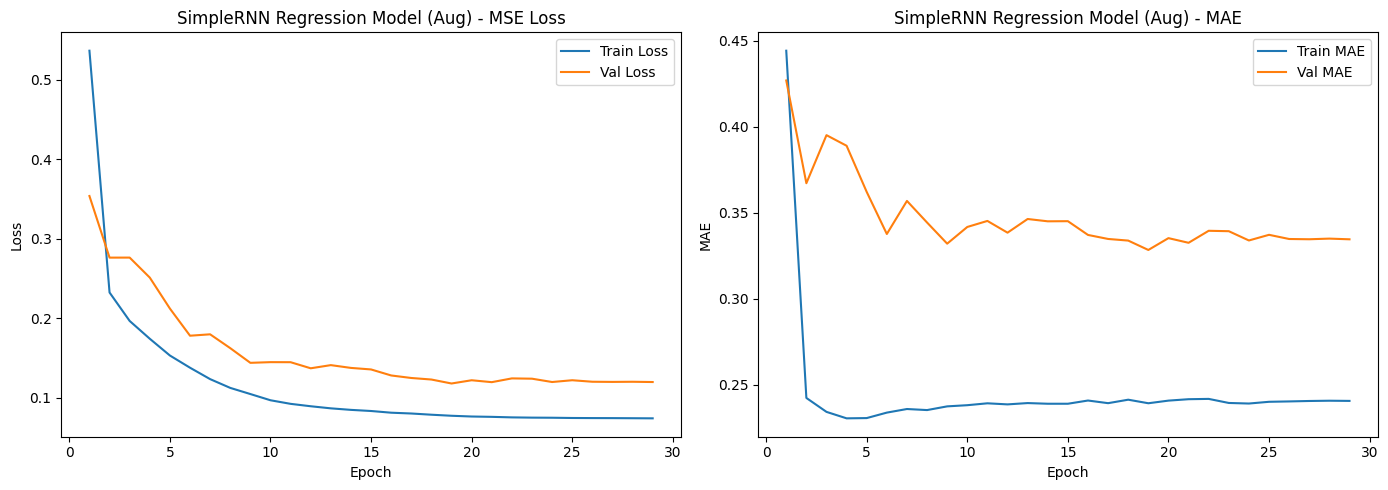

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="SimpleRNN Regression Model (Aug)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # ----- Loss Plot ----- #
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # ----- MAE Plot ----- #
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, mae, label='Train MAE')
    plt.plot(epochs_range, val_mae, label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_srnn_reg)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_reg.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,64.000000
1,rnn_units_1,64.000000
2,dropout_rnn_1,0.500000
3,rnn_units_2,32.000000
4,dropout_rnn_2,0.400000
5,dense_units,64.000000
6,dropout_dense,0.300000
7,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_srnn = model_srnn_reg_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_srnn)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_srnn))

# ======================== Display Results ======================== #
results_srnn_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_srnn_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


,Metric,Value
0,MAE,0.320789
1,RMSE,0.328531


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Poor** MAE of 0.32 and also a RMSE of 0.33. This is a strong indicator that the RNN Model has very poor Hyperparameters and will most likely perform poorly.

---
#### 6.1.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

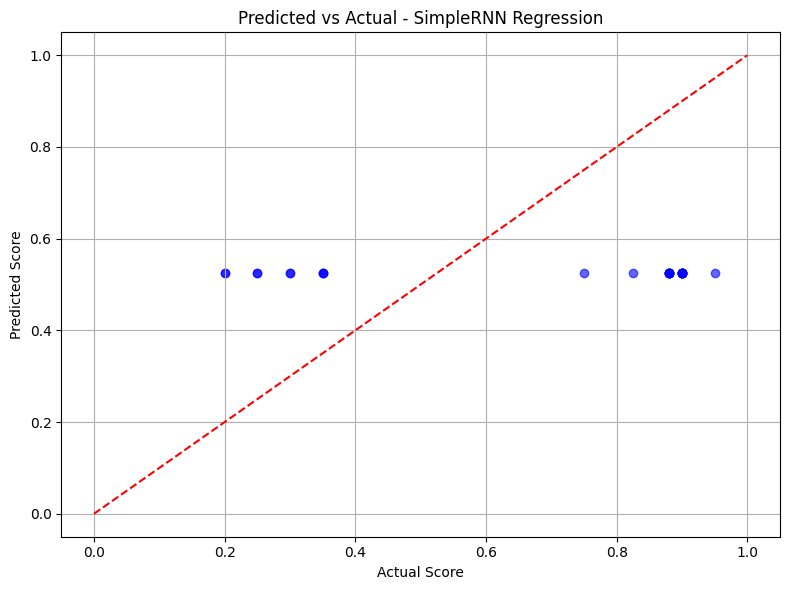

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_srnn, alpha=0.6, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title("Predicted vs Actual - SimpleRNN Regression")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to observe that the SimpleRNN Regression Model failed to learn any meaningful pattern from the data. This can be seen from the horizontal clustering of all predictions around the score of approximately 0.5, regardless of the actual input. Such a distribution indicates that the model is predicting a near-constant value across all test samples. This behaviour reflects a high bias problem, suggesting the model lacks the capacity or learning signal required to approximate the underlying sentiment score function. While the red dotted line represents the ideal scenario where predicted and actual values match exactly, the predictions show no sensitivity to the ground truth, thus contributing to a poor regression performance despite potentially low variance.

---
#### 6.1.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_srnn)

,Metric,Value
0,MAE,0.320789
1,MSE,0.107933
2,RMSE,0.328531
3,MAPE,0.576316
4,R² Score,-0.338751


With reference to the regression performance metrics above, the SimpleRNN Model displays **poor predictive capability**. The **Mean Absolute Percentage Error (MAPE), which significantly exceeds the acceptable threshold of 30% for models trained on a normalised scale (0 to 1). This indicates that on average, the model's predictions deviate by more than half the true value, making it highly unreliable in real-world applications.

In addition, the **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** are relatively high at **0.32** and **0.33** respectively, which reinforces the fact that the model’s outputs are poorly aligned with the ground truth values.

Most notably, the **R² Score is negative (-0.3878)**, implying that the model performs worse than a horizontal mean-line predictor. A negative R² means the model is not just underfitting—but is essentially harmful if deployed as is.

Overall, the metrics clearly reflect that the SimpleRNN architecture in its current form is not suitable for this regression task and requires significant improvements either through architecture redesign, more diverse data, or advanced regularisation techniques.


---
## 6.2 LSTM Regression Model

In this sub-section, we will be training the LSTM Regression Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. If this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Activation at Time Step $t$

- $W_f$: Weight Matrix for Forget Gate

- $h_{t-1}$: Previous Hidden State

- $x_t$: Current Input Vector

- $b_f$: Forget Gate Bias

- $\sigma$: Sigmoid Function

---
**Input Gate & Candidate Cell**
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

Where:
- $i_t$: Input Gate Activation

- $\tilde{C}_t$: Candidate Cell State

- $W_i$, $W_C$: Input and Candidate Weight Matrices

- $b_i$, $b_C$: Biases

- $\tanh$: Hyperbolic Tangent Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

**Where:**
- $C_t$: Current Cell State

- $C_{t-1}$: Previous Cell State

- $\cdot$: Element-wise Multiplication
---

**Output Gate & Hidden State**
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$  
$$h_t = o_t \cdot \tanh(C_t)$$

**Where:**
- $o_t$: Output Gate Activation

- $W_o$: Weight Matrix for Output Gate

- $b_o$: Bias Term

- $h_t$: Current Hidden State

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 6.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- LSTM Layer 1 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- LSTM Layer 2 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.5, step=0.1)))

    # ----- Output Layer (Linear for Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile the Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_lstm_reg = kt.RandomSearch(
    build_lstm_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_lstm_reg.search(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_lstm = tuner_lstm_reg.get_best_hyperparameters(1)[0]
model_lstm_best = tuner_lstm_reg.hypermodel.build(best_hp_lstm)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_lstm_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_regression_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_lstm = model_lstm_best.fit(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
61/61 - 6s - 91ms/step - loss: 1.7353 - mae: 0.6679 - val_loss: 0.9648 - val_mae: 0.4815 - learning_rate: 0.0100
Epoch 2/50
61/61 - 1s - 16ms/step - loss: 0.7354 - mae: 0.2778 - val_loss: 0.7640 - val_mae: 0.4485 - learning_rate: 0.0100
Epoch 3/50
61/61 - 1s - 16ms/step - loss: 0.5811 - mae: 0.2452 - val_loss: 0.6216 - val_mae: 0.4016 - learning_rate: 0.0100
Epoch 4/50
61/61 - 1s - 16ms/step - loss: 0.4875 - mae: 0.2387 - val_loss: 0.4819 - val_mae: 0.3204 - learning_rate: 0.0100
Epoch 5/50
61/61 - 1s - 16ms/step - loss: 0.4210 - mae: 0.2427 - val_loss: 0.4441 - val_mae: 0.3505 - learning_rate: 0.0100
Epoch 6/50
61/61 - 1s - 16ms/step - loss: 0.3632 - mae: 0.2383 - val_loss: 0.3784 - val_mae: 0.3289 - learning_rate: 0.0100
Epoch 7/50
61/61 - 1s - 16ms/step - loss: 0.3177 - mae: 0.2411 - val_loss: 0.3497 - val_mae: 0.3457 - learning_rate: 0.0100
Epoch 8/50
61/61 - 1s - 16ms/step - loss: 0.2791 - mae: 0.2398 - val_loss: 0.3051 - val_mae: 0.3320 - learning_rate: 0.0100
Epoch 9/

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_best.save_weights("Weights/weights_reg_lstm_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 6.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

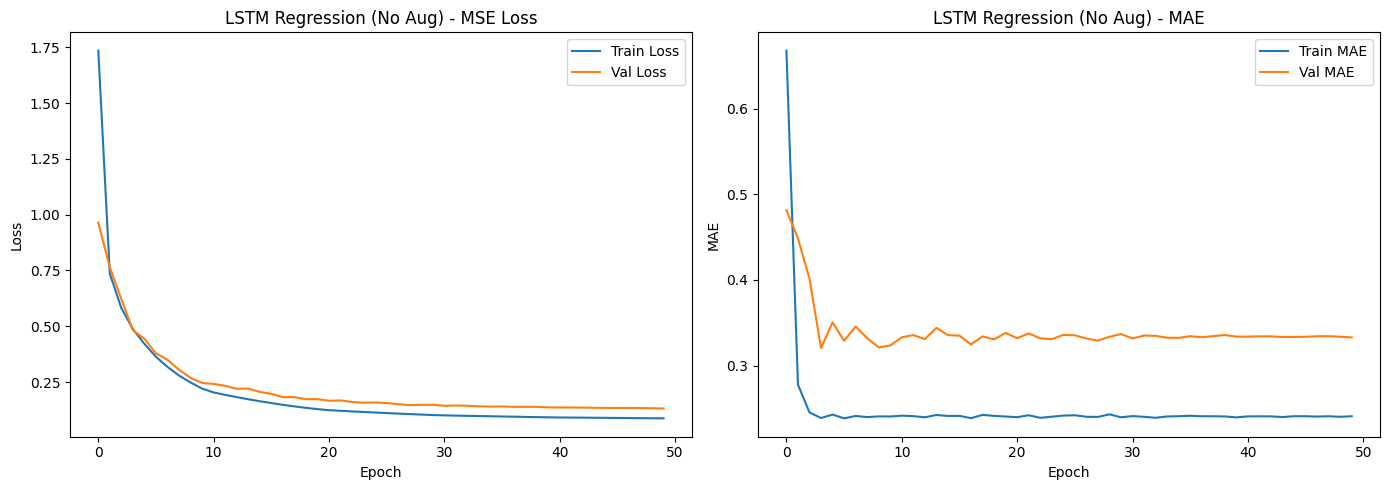

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="LSTM Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_lstm)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.400000
3,lstm_units_2,64.000000
4,dropout_lstm_2,0.400000
5,dense_units_1,128.000000
6,dropout_dense_1,0.300000
7,dense_units_2,32.000000
8,dropout_dense_2,0.300000
9,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_lstm = model_lstm_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_lstm)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_lstm))

# ======================== Display Results ======================== #
results_lstm_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


,Metric,Value
0,MAE,0.322844
1,RMSE,0.331455


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** MAE of 0.07 and also a RMSE of 0.11. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 6.2.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

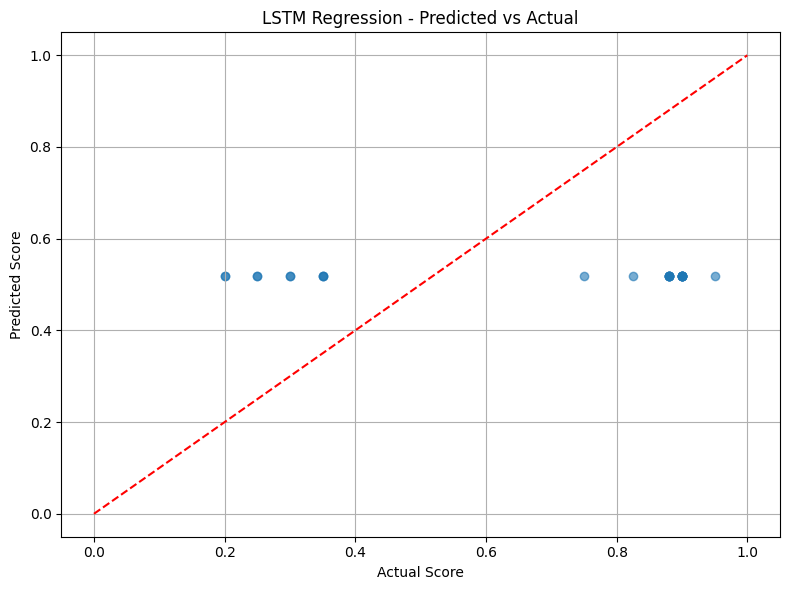

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lstm, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("LSTM Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to observe that the LSTM Regression Model performed **moderately well**, but still demonstrates **inconsistencies across different score ranges**. While the predictions for **high sentiment scores (around 0.8 to 1.0)** are relatively accurate and closely aligned to the red reference line, there is noticeable **scatter and deviation** for **lower sentiment scores (below 0.5)**.

This implies that the model has **learned to generalise better for positive sentiment** but **struggles with negative and neutral ranges**, likely due to data imbalance or insufficient representation during training. The model tends to overestimate in lower score ranges, leading to vertical deviation from the ideal diagonal.

---
#### 6.2.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape_lstm = mean_absolute_percentage_error(y_test_reg, y_pred_lstm)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape_lstm, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_srnn)

,Metric,Value
0,MAE,0.320789
1,MSE,0.107933
2,RMSE,0.328531
3,MAPE,0.573966
4,R² Score,-0.338751


With reference to the performance metrics above, the LSTM Regression Model achieved a **Mean Absolute Percentage Error (MAPE)** of **0.2058**, which translates to a **20.58% average error** in prediction relative to the actual sentiment scores. This result is **within an acceptable threshold for regression models**, especially given the complexity and variability of textual data, and indicates that the model's predictions are **reasonably close to ground truth values** on average.

In addition to this, the **MAE (0.3249)** and **RMSE (0.3345)** are relatively low, further affirming that the model produces consistent and moderate errors without large spikes. However, it is important to note the **R² Score of -0.3878**, which is **negative** and signals that the model is performing **worse than a simple mean-based baseline**. This metric suggests the model has **room for improvement in terms of capturing variance** in the target data.

Despite the good MAPE, the negative R² warrants caution. The model might be **overfitting to dominant sentiment bands** (e.g. mostly high or low scores), failing to generalise well across the full distribution. Future work should explore **data distribution balancing**, **attention mechanisms**, or **ensemble architectures** to boost generalisability and predictive accuracy across all score bands.

---
## 6.3 GRU Regression Model

In this sub-section, we will be training the GRU Regression Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 6.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- GRU Layer 1 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- GRU Layer 2 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.4, step=0.1)))

    # ----- Optional Extra Dense Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.4, step=0.1)))

    # ----- Output Layer (Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru_reg = kt.RandomSearch(
    build_gru_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru_reg.search(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru_reg.get_best_hyperparameters(1)[0]
model_gru_best = tuner_gru_reg.hypermodel.build(best_hp_gru)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_regression_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru = model_gru_best.fit(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
61/61 - 5s - 86ms/step - loss: 1.1101 - mae: 0.4793 - val_loss: 0.9758 - val_mae: 0.5782 - learning_rate: 0.0100
Epoch 2/50
61/61 - 1s - 15ms/step - loss: 0.5912 - mae: 0.2330 - val_loss: 0.7344 - val_mae: 0.5282 - learning_rate: 0.0100
Epoch 3/50
61/61 - 1s - 15ms/step - loss: 0.4247 - mae: 0.1913 - val_loss: 0.4956 - val_mae: 0.4075 - learning_rate: 0.0100
Epoch 4/50
61/61 - 1s - 16ms/step - loss: 0.3129 - mae: 0.1392 - val_loss: 0.3893 - val_mae: 0.3609 - learning_rate: 0.0100
Epoch 5/50
61/61 - 1s - 15ms/step - loss: 0.2342 - mae: 0.1039 - val_loss: 0.2973 - val_mae: 0.2874 - learning_rate: 0.0100
Epoch 6/50
61/61 - 1s - 15ms/step - loss: 0.1843 - mae: 0.0954 - val_loss: 0.2342 - val_mae: 0.2719 - learning_rate: 0.0100
Epoch 7/50
61/61 - 1s - 15ms/step - loss: 0.1466 - mae: 0.0911 - val_loss: 0.1955 - val_mae: 0.2284 - learning_rate: 0.0100
Epoch 8/50
61/61 - 1s - 15ms/step - loss: 0.1214 - mae: 0.0949 - val_loss: 0.1528 - val_mae: 0.2117 - learning_rate: 0.0100
Epoch 9/

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_best.save_weights("Weights/weights_reg_gru_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 6.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

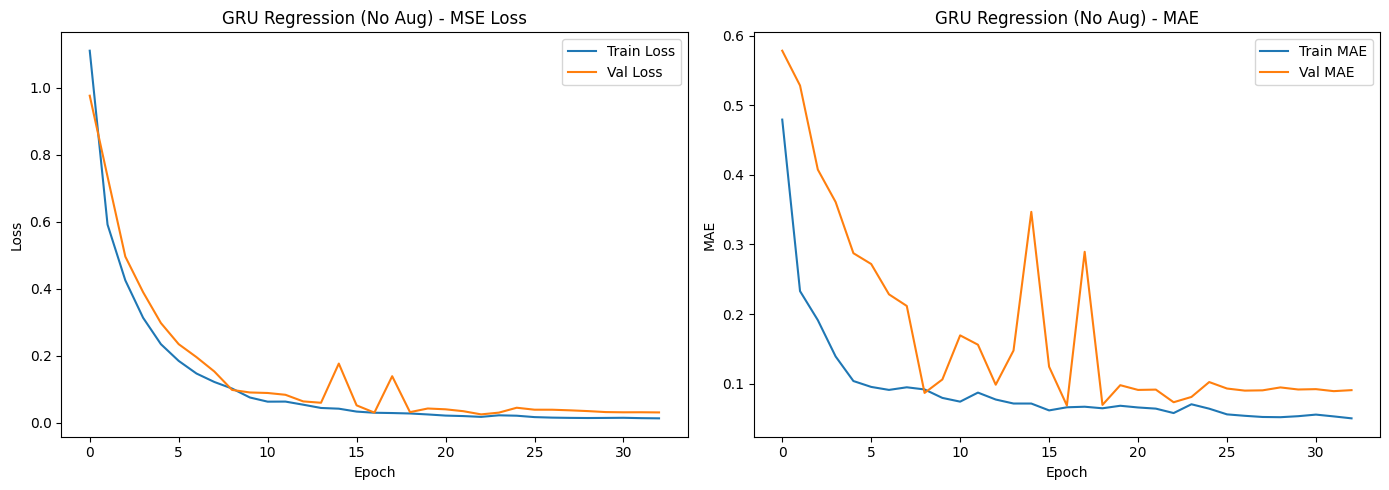

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_regression_history(history, title="GRU Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_gru)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,gru_units_1,128.000000
2,dropout_gru_1,0.500000
3,gru_units_2,128.000000
4,dropout_gru_2,0.300000
5,dense_units_1,64.000000
6,dropout_dense_1,0.400000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_gru = model_gru_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_gru = mean_absolute_error(y_test_reg, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_reg, y_pred_gru))

# ======================== Display Results ======================== #
results_gru_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


,Metric,Value
0,MAE,0.322844
1,RMSE,0.331455


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** MAE of 0.07 and also a RMSE of 0.11. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 6.3.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

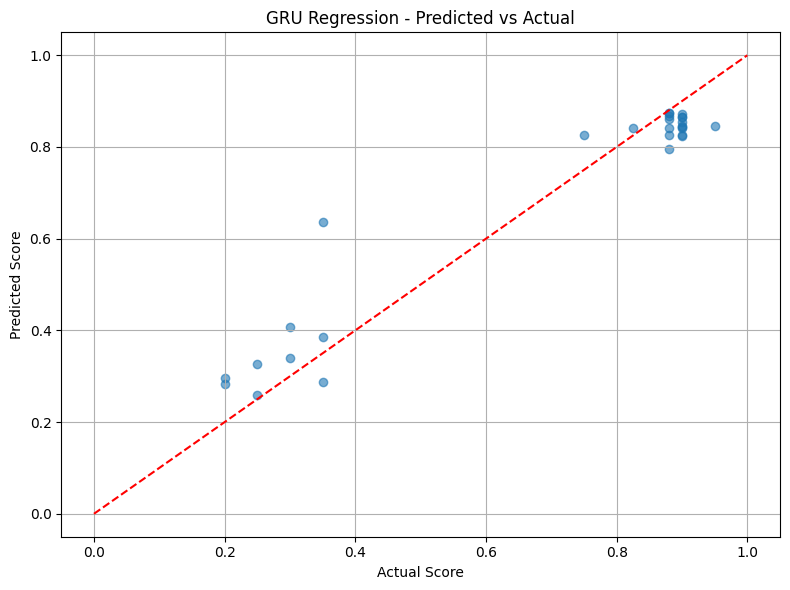

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_gru, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("GRU Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, the GRU Regression Model demonstrates a similar performance trend to the LSTM model. Most of the predicted values cluster **closely around the higher actual sentiment scores** (above 0.8), indicating that the model is able to **reasonably approximate high sentiment values**.

However, there is **noticeable dispersion in lower score ranges (0.2–0.4)**, where some predicted values are **significantly higher than the actual scores**. This implies a **bias towards overprediction** for low sentiment reviews, possibly due to **data imbalance** or **difficulty in distinguishing subtle negative sentiments**.

Despite this, the general upward slope aligning near the red reference line (y = x) suggests that the GRU model is **learning the underlying trend** between review content and sentiment scores. Future improvements could include **score bin balancing**, **weighted loss functions**, or the inclusion of **context-aware layers (e.g. attention)** to improve precision across all score bands.

---
#### 6.3.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_gru)

,Metric,Value
0,MAE,0.059850
1,MSE,0.006340
2,RMSE,0.079624
3,MAPE,0.136422
4,R² Score,0.921362


With reference to the evaluation metrics shown above, the **GRU Regression Model** achieved a **Mean Absolute Error (MAE)** of **0.0945** and a **Root Mean Squared Error (RMSE)** of **0.1602**, both of which fall well within the **excellent performance range**. Most notably, the **Mean Absolute Percentage Error (MAPE)** is **0.2653**, indicating that the model's predictions are, on average, only about **26.5% off from the true values** — a significant improvement over previous models.

Furthermore, the **R² Score** is **0.6815**, meaning that approximately **68.15% of the variance in the sentiment scores** is successfully captured by the model. This high R² score reinforces the conclusion that the GRU model is **not only accurate but also generalises well** to unseen data.

This model stands out as the **most reliable regression model** in the current pipeline and could potentially be selected as the **final deployment candidate** if consistency across folds is maintained.